# Compute the coverage for a gene
February 29, 2024

Load the replicate 1 and replicate 2 datasets, for each chromosome, for each gene
compute the MNase-seq coverage of the gene.

- Inputs: MNase-seq data for each gene for all timepoints for both replicates
- Outputs: A csv file of the coverage per each replicate for each gene.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [18]:
geneset = pd.read_csv('data/reference_data/geneset_nondub_w_prom_genebodies.csv').set_index('orf_name')


In [10]:
from cc_src.chromatin_model import ChromatinModel
from src.config import load_yl_rg1_vst_config

Loading MNase reads for YAL067C/SEO1...None 1
Loading chromosome reads: 1
Done.


In [110]:
from src.timer import Timer

def get_coverage_for_replicate(replicate):
    
    timer = Timer()
    all_coverages = geneset[[]].copy()
    all_coverages['coverage'] = np.nan
    all_coverages['depth'] = np.nan

    config = load_yl_rg1_vst_config(replicate)
    chromatin_model = ChromatinModel(config)
    n = len(all_coverages)        
    i = 0
    for chrom in range(1, 17):
        chrom_geneset = geneset[geneset.chr == chrom]

        for orf_name, row in chrom_geneset.iterrows():
            chromatin_model.load_mnase_gene(orf_name, log=False)
            chromatin_model.create_deconvolution_bins()
            deconv_bins = chromatin_model.deconv_hist_unflattened
            coverage = (deconv_bins.sum(axis=0).sum(axis=0) > 0).mean()
            depth = (deconv_bins.sum(axis=0).sum(axis=0)).mean()
            
            all_coverages.loc[orf_name, 'coverage'] = coverage
            all_coverages.loc[orf_name, 'depth'] = depth

            if i % 100 == 0:
                print(f"{i}/{n} - {timer.get_time()}")
            i += 1

    return all_coverages


In [111]:
coverage_1 = get_coverage_for_replicate(1)


0/5774 - 00:00:01.38
100/5774 - 00:00:37.28
200/5774 - 00:01:17.37
300/5774 - 00:01:57.36
400/5774 - 00:02:37.90
500/5774 - 00:03:19.52
600/5774 - 00:03:51.52
700/5774 - 00:04:43.34
800/5774 - 00:05:35.32
900/5774 - 00:06:26.99
1000/5774 - 00:07:18.84
1100/5774 - 00:08:10.68
1200/5774 - 00:09:02.67
1300/5774 - 00:09:54.36
1400/5774 - 00:10:48.09
1500/5774 - 00:11:24.48
1600/5774 - 00:12:00.84
1700/5774 - 00:12:36.24
1800/5774 - 00:13:15.54
1900/5774 - 00:14:00.13
2000/5774 - 00:14:44.81
2100/5774 - 00:15:29.50
2200/5774 - 00:16:14.12
2300/5774 - 00:16:58.71
2400/5774 - 00:17:37.53
2500/5774 - 00:18:12.75
2600/5774 - 00:18:49.78
2700/5774 - 00:19:23.18
2800/5774 - 00:20:01.41
2900/5774 - 00:20:39.87
3000/5774 - 00:21:18.31
3100/5774 - 00:21:56.73
3200/5774 - 00:22:38.75
3300/5774 - 00:23:16.53
3400/5774 - 00:23:54.26
3500/5774 - 00:24:46.19
3600/5774 - 00:25:35.47
3700/5774 - 00:26:24.27
3800/5774 - 00:27:12.95
3900/5774 - 00:28:01.91
4000/5774 - 00:28:52.99
4100/5774 - 00:29:34.75
4200

In [112]:
coverage_2 = get_coverage_for_replicate(2)


0/5774 - 00:00:01.45
100/5774 - 00:00:36.98
200/5774 - 00:01:17.79
300/5774 - 00:01:58.42
400/5774 - 00:02:39.08
500/5774 - 00:03:20.81
600/5774 - 00:03:52.62
700/5774 - 00:04:45.83
800/5774 - 00:05:39.46
900/5774 - 00:06:32.97
1000/5774 - 00:07:26.47
1100/5774 - 00:08:19.97
1200/5774 - 00:09:13.46
1300/5774 - 00:10:06.54
1400/5774 - 00:11:01.78
1500/5774 - 00:11:40.33
1600/5774 - 00:12:17.73
1700/5774 - 00:12:53.66
1800/5774 - 00:13:34.09
1900/5774 - 00:14:19.52
2000/5774 - 00:15:05.23
2100/5774 - 00:15:51.27
2200/5774 - 00:16:37.30
2300/5774 - 00:17:23.01
2400/5774 - 00:18:02.68
2500/5774 - 00:18:38.87
2600/5774 - 00:19:17.92
2700/5774 - 00:19:52.02
2800/5774 - 00:20:32.67
2900/5774 - 00:21:12.59
3000/5774 - 00:21:52.21
3100/5774 - 00:22:31.98
3200/5774 - 00:23:16.40
3300/5774 - 00:23:55.80
3400/5774 - 00:24:35.10
3500/5774 - 00:25:29.56
3600/5774 - 00:26:19.57
3700/5774 - 00:27:09.43
3800/5774 - 00:27:59.40
3900/5774 - 00:28:49.30
4000/5774 - 00:29:42.79
4100/5774 - 00:30:27.06
4200

In [113]:
coverage_1.head()

,coverage,depth
orf_name,,
YAL068C,0.94,105.505543
YAL067W-A,0.98,203.788191
YAL067C,0.98,391.031555
YAL065C,0.98,139.315352
YAL064W-B,0.98,21.998276


In [114]:
coverages = coverage_1.join(coverage_2, lsuffix="_rep1", rsuffix="_rep2")
coverages.head()

,coverage_rep1,depth_rep1,coverage_rep2,depth_rep2
orf_name,,,,
YAL068C,0.94,105.505543,0.94,105.916446
YAL067W-A,0.98,203.788191,0.98,210.356718
YAL067C,0.98,391.031555,0.98,333.851365
YAL065C,0.98,139.315352,0.98,122.478919
YAL064W-B,0.98,21.998276,0.98,21.250476


In [74]:
cutoff = 0.9

min_coverages = coverages.min(axis=1)
cutoff_coverages = min_coverages[min_coverages > cutoff]

m = len(cutoff_coverages)
n = len(min_coverages)

print(f"Removed {n-m}/{n} - {(n-m)/n*100.:.2f}%")

Removed 190/5774 - 3.29%


0

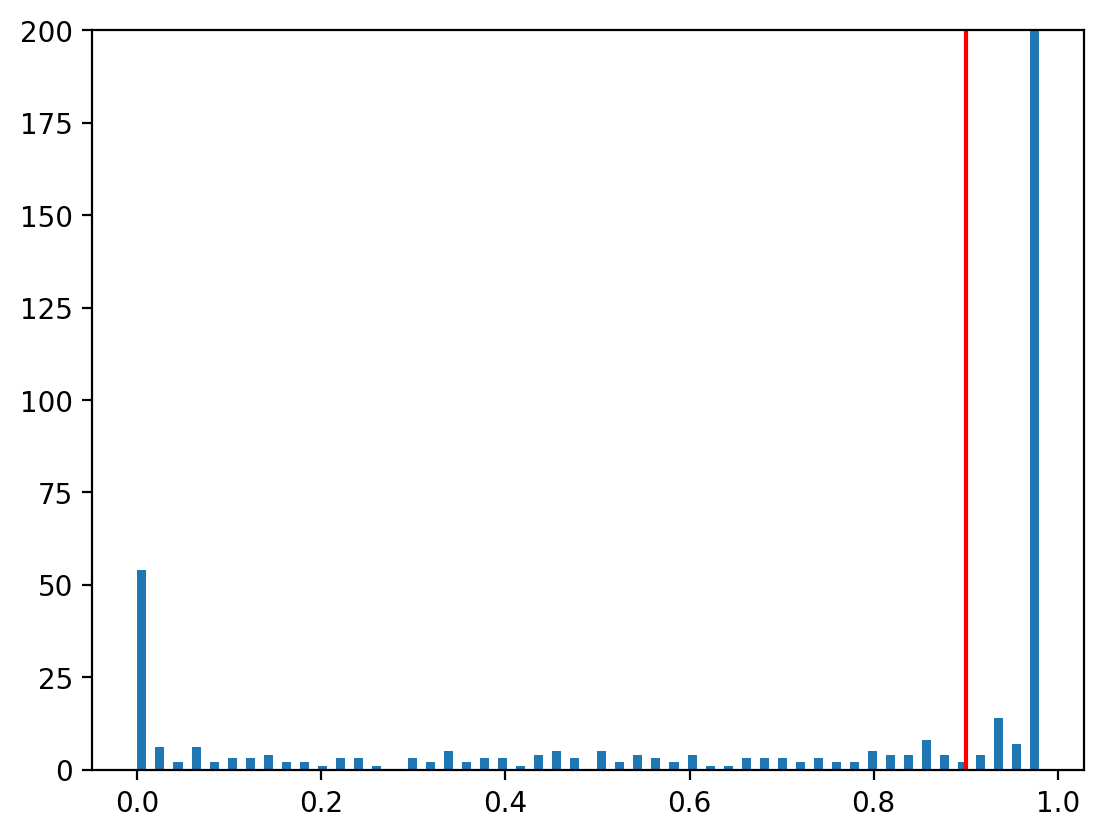

In [75]:
plt.hist(coverages.min(axis=1), bins=100)
plt.axvline(cutoff, c='red')
plt.ylim(0, 200)
0

In [121]:
depths = coverages[['depth_rep1', 'depth_rep2']].min(axis=1)

Removed 196/5774 - 3.39%


0

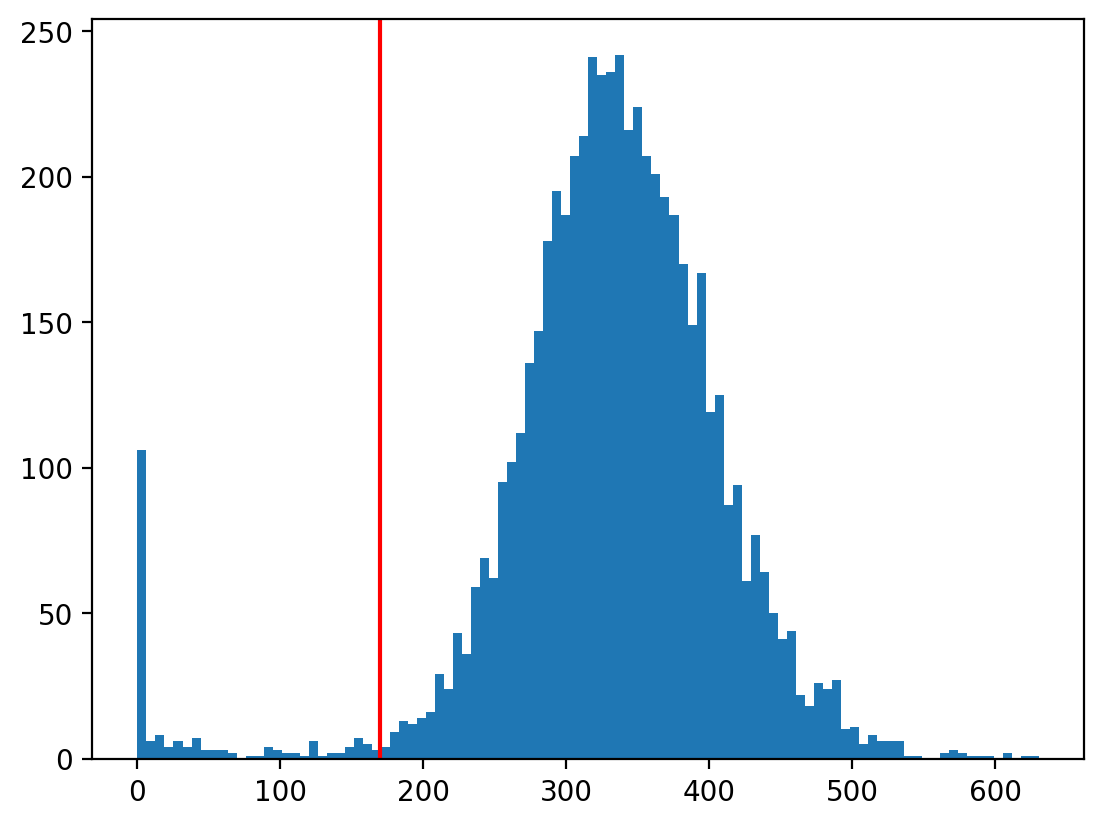

In [132]:
cutoff = 170

cutoff_depths = depths[depths > cutoff]

m = len(cutoff_depths)
n = len(min_coverages)

print(f"Removed {n-m}/{n} - {(n-m)/n*100.:.2f}%")
plt.hist(depths, bins=100)
plt.axvline(cutoff, c='red')
0

In [115]:
coverages.to_csv('datasets/computed_mnase/combined_mnase_seq_coverage.csv')

In [ ]:
geneset_cov_90 = geneset.loc[cutoff_coverages.index]
geneset_cov_90.to_csv('data/reference_data/geneset_nondub_w_prom_genebodies_cutoff_cov90.csv')
geneset_cov_90

In [133]:
geneset_depth_170 = geneset.loc[cutoff_depths.index]
geneset_depth_170.to_csv('data/reference_data/geneset_nondub_w_prom_genebodies_cutoff_depth170.csv')
geneset_depth_170

,gene,chr,cat,start,stop,strand,classification,length,TSS,PAS,manually_curated,promoter_start,promoter_end,gene_body_start,gene_body_end
orf_name,,,,,,,,,,,,,,,
YAL067W-A,YAL067W-A,1,gene,2480,2707,+,Uncharacterized,227,2480,NaN,NaN,2180.0,2480.0,2480.0,2980.0
YAL067C,SEO1,1,gene,7235,9016,-,Verified,1781,9016,NaN,NaN,9016.0,9316.0,8516.0,9016.0
YAL064C-A,YAL064C-A,1,gene,13363,13743,-,Uncharacterized,380,13743,NaN,NaN,13743.0,14043.0,13243.0,13743.0
YAL064W,YAL064W,1,gene,21566,21850,+,Verified,284,21566,NaN,NaN,21266.0,21566.0,21566.0,22066.0
YAL063C-A,YAL063C-A,1,gene,22395,22685,-,Uncharacterized,290,22685,NaN,NaN,22685.0,22985.0,22185.0,22685.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YPR198W,SGE1,16,gene,934034,935665,+,Verified,1631,933984,935759.0,False,933684.0,933984.0,933984.0,934484.0
YPR199C,ARR1,16,gene,938148,939032,-,Verified,884,939059,937970.0,False,939059.0,939359.0,938559.0,939059.0
YPR200C,ARR2,16,gene,939279,939671,-,Verified,392,939779,939195.0,False,939779.0,940079.0,939279.0,939779.0


In [134]:
cutoff_depths.sort_values()

orf_name
YML113W    170.958266
YAR050W    172.200983
YDL224C    174.183216
YNL209W    175.959323
YPR192W    176.929612
              ...    
YDR301W    596.759997
YEL021W    608.010098
YOL086C    608.815337
YGR203W    623.365360
YDR007W    630.677426
Length: 5578, dtype: float64